# 01 - Data Exploration
**AquaGuard Component C - ML Anomaly Detection, RUL & Failure-Mode Classification**

This notebook explores the fused feature set that Component B hands off to Component C:
one row per pump per hour, combining mechanical sensors (A1), water-quality sensors (A2),
weather data, and Component B's own engineered features (rolling stats, lag features,
weather-conditioned baselines, and the Pump Stress Index).

The data here is **synthetic Phase-A rehearsal data** — built to be structurally identical
to what real NWSDB sensor deployment will eventually produce, so the whole Component C
pipeline can be built and validated before real data arrives (see both the Component B
and Component C technical procedure documents).

In [1]:
import sys, os
sys.path.append(os.path.abspath('..'))
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')
%matplotlib inline

from src import config, data_loader, preprocessing, evaluate


## Load the fully-fused dataset (Variant 3 input)

In [2]:
df = data_loader.load_variant('variant3')
print(df.shape)
df.head()

(7203, 30)


,pump_id,timestamp,vibration_rms_g,vibration_peak_freq_hz,temperature_c,acoustic_level_db,current_draw_a,vibration_rms_roll_mean_6h,vibration_rms_roll_std_6h,ph,...,ph_lag_6h,water_aggression_index_lag_24h,turbidity_baseline_expected,turbidity_deviation_from_baseline,pump_stress_index,RUL_days,right_censored,failure_mode_label,anomaly_label,data_split
0,PUMP_01,2026-03-01 00:00:00,0.1669,50.31,33.72,59.43,4.076,0.1669,0.0000,7.222,...,7.222,13.16,4.0,-0.58,7.38,90.00,True,Normal,0,train
1,PUMP_01,2026-03-01 01:00:00,0.1721,52.37,34.96,59.69,4.034,0.1695,0.0037,7.252,...,7.222,13.16,4.0,0.44,9.00,89.96,True,Normal,0,train
2,PUMP_01,2026-03-01 02:00:00,0.1816,51.56,34.35,56.42,4.091,0.1735,0.0075,7.218,...,7.222,13.16,4.0,0.54,8.87,89.92,True,Normal,0,train
3,PUMP_01,2026-03-01 03:00:00,0.1590,51.59,33.77,56.60,3.949,0.1699,0.0095,7.155,...,7.222,13.16,4.0,-0.30,5.32,89.88,True,Normal,0,train
4,PUMP_01,2026-03-01 04:00:00,0.1701,49.38,33.61,57.65,3.934,0.1699,0.0082,7.078,...,7.222,13.16,4.0,-0.25,6.03,89.83,True,Normal,0,train


## Pumps in this dataset and their scenario
Ground truth is embedded only because this is synthetic rehearsal data - in the real deployment these outcomes are exactly what Component C is trying to *predict*.

In [3]:
for pump_id, g in df.groupby('pump_id'):
    modes = g['failure_mode_label'].unique()
    fail_rows = g[g['failure_mode_label'] != 'Normal']
    onset = fail_rows['timestamp'].min() if len(fail_rows) else None
    end = g['timestamp'].max()
    print(f"{pump_id}: {len(g):5d} hourly rows | modes seen: {sorted(modes)} | "
          f"degradation onset: {onset} | series ends: {end}")

PUMP_01:  2160 hourly rows | modes seen: ['Normal'] | degradation onset: None | series ends: 2026-05-29 23:00:00
PUMP_02:  1681 hourly rows | modes seen: ['Mechanical', 'Normal'] | degradation onset: 2026-04-15 00:00:00 | series ends: 2026-05-10 00:00:00
PUMP_03:  1321 hourly rows | modes seen: ['Chemical', 'Normal'] | degradation onset: 2026-03-31 00:00:00 | series ends: 2026-04-25 00:00:00
PUMP_04:  2041 hourly rows | modes seen: ['Mechanical', 'Normal'] | degradation onset: 2026-04-30 00:00:00 | series ends: 2026-05-25 00:00:00


## Class balance for the Stage 3 target (`failure_mode_label`)

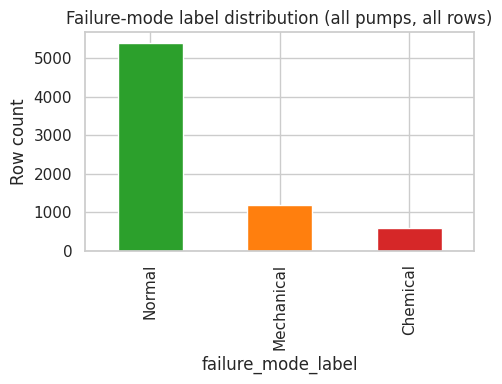

failure_mode_label
Normal        5400
Mechanical    1202
Chemical       601
Name: count, dtype: int64

In [4]:
counts = df['failure_mode_label'].value_counts()
ax = counts.plot(kind='bar', color=['#2ca02c', '#ff7f0e', '#d62728'], figsize=(5,4))
ax.set_title('Failure-mode label distribution (all pumps, all rows)')
ax.set_ylabel('Row count')
plt.tight_layout()
plt.show()
counts

## Mechanical vs. water-quality trends for a healthy pump vs. a failing pump
`PUMP_01` never fails in this window. `PUMP_02` fails mechanically around day 70.

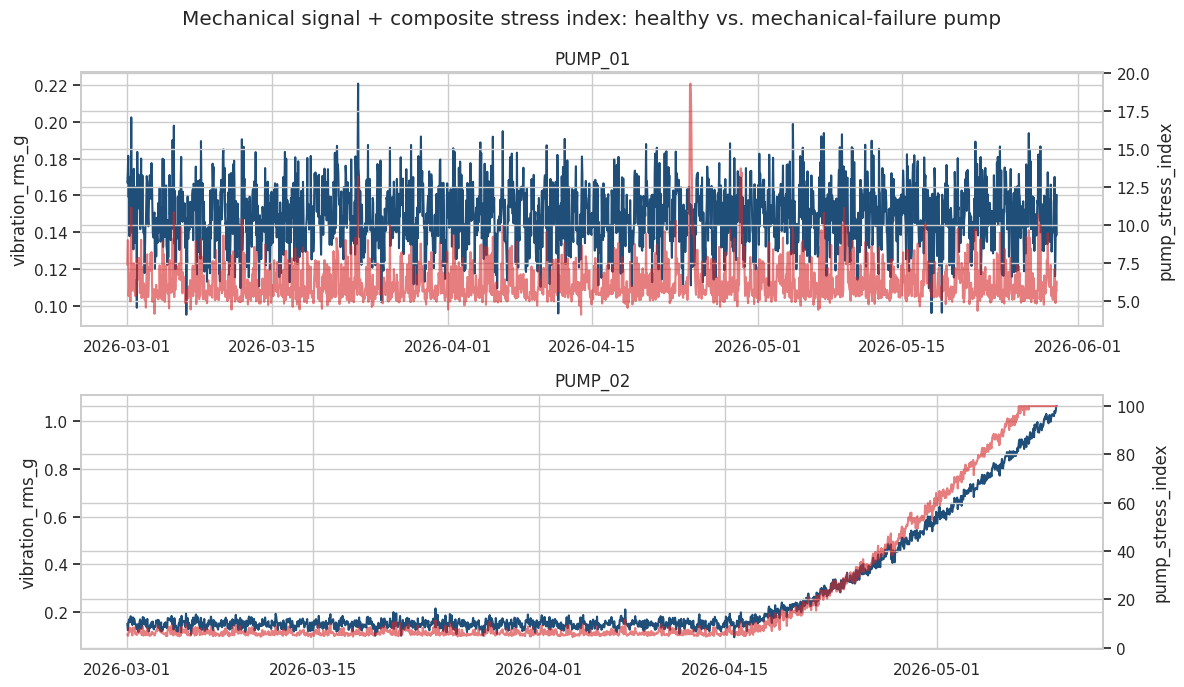

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=False)
for ax, pump_id in zip(axes, ['PUMP_01', 'PUMP_02']):
    g = df[df.pump_id == pump_id]
    ax.plot(g['timestamp'], g['vibration_rms_g'], label='vibration_rms_g', color='#1f4e79')
    ax2 = ax.twinx()
    ax2.plot(g['timestamp'], g['pump_stress_index'], label='pump_stress_index',
             color='#d62728', alpha=0.6)
    ax.set_title(f'{pump_id}')
    ax.set_ylabel('vibration_rms_g')
    ax2.set_ylabel('pump_stress_index')
fig.suptitle('Mechanical signal + composite stress index: healthy vs. mechanical-failure pump')
fig.tight_layout()
plt.show()

## The causal chain on the chemical-failure pump (`PUMP_03`)
Component B's whole research contribution is testing whether *rainfall → water quality → mechanical stress* is a real, laggy chain. Here's what that looks like for the pump whose synthetic failure is water-quality-driven.

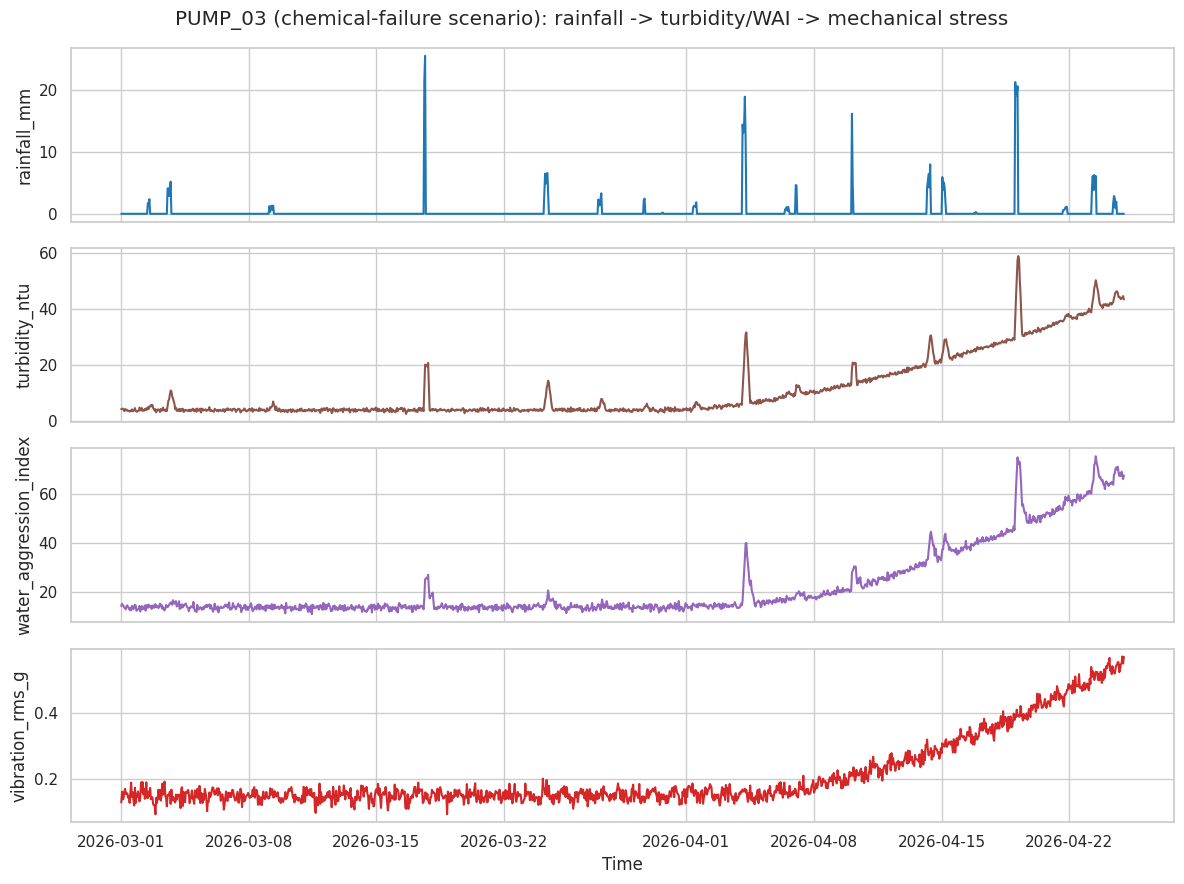

In [6]:
g = df[df.pump_id == 'PUMP_03']
fig, axes = plt.subplots(4, 1, figsize=(12, 9), sharex=True)
axes[0].plot(g['timestamp'], g['rainfall_mm'], color='#1f77b4')
axes[0].set_ylabel('rainfall_mm')
axes[1].plot(g['timestamp'], g['turbidity_ntu'], color='#8c564b')
axes[1].set_ylabel('turbidity_ntu')
axes[2].plot(g['timestamp'], g['water_aggression_index'], color='#9467bd')
axes[2].set_ylabel('water_aggression_index')
axes[3].plot(g['timestamp'], g['vibration_rms_g'], color='#d62728')
axes[3].set_ylabel('vibration_rms_g')
axes[3].set_xlabel('Time')
fig.suptitle('PUMP_03 (chemical-failure scenario): rainfall -> turbidity/WAI -> mechanical stress')
fig.tight_layout()
plt.show()

## Feature correlation with RUL_days (Variant 3 features)
A quick sanity check that the engineered features actually move together with how close a pump is to failure - useful before committing to a modelling approach.

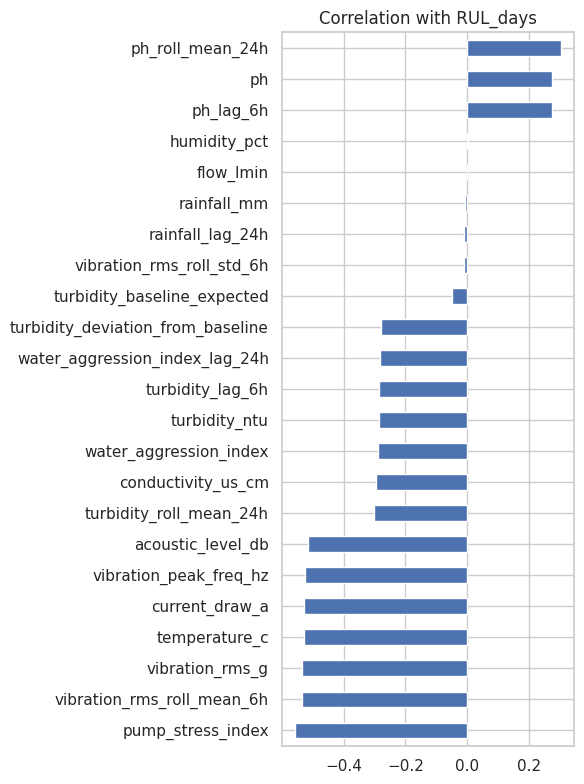

In [7]:
feature_cols = config.FEATURE_COLS['variant3']
corr = df[feature_cols + ['RUL_days']].corr()['RUL_days'].drop('RUL_days').sort_values()
fig, ax = plt.subplots(figsize=(6, 8))
corr.plot(kind='barh', ax=ax, color='#4c72b0')
ax.set_title('Correlation with RUL_days')
plt.tight_layout()
plt.show()

**Takeaway:** mechanical stress and water-aggression features trend down with RUL (they rise as failure approaches), which is exactly the signal Stage 1/2/3 of Component C need to learn from. Next notebook: `02_stage1_anomaly_detection.ipynb`.